# Introduction to the Digital Earth Africa Water Quality Monitoring Service (WQMS)

* **Products used:** 
[wq_annual](https://explorer.dev.digitalearth.africa/products/wq_annual),
[ls8_sr](https://explorer.digitalearth.africa/products/ls8_sr),
[wofs_ls_summary_annual](https://explorer.digitalearth.africa/wofs_ls_summary_annual)

## Background
The Water Quality Monitoring Service (WQMS) delivers water quality information for surface water bodies across across the African continent. Earth Observation (EO) data provides continuous spatial coverage and change monitoring at a fraction of the cost and logistical complexity of in-situ monitoring. As national governments across Africa work to address Sub-indicator 2 of [Sustainable Development Goal (SDG) 6.6.1](https://www.unwater.org/our-work/sdg-6-integrated-monitoring-initiative/indicator-661-change-extent-water-related) — Water Quality of Lakes and Artificial Water Bodies — the Water Quality Monitoring System (WQMS) will provide timely, decision-relevant information to support the management and sustainable use of surface water resources. This includes indicators such as overall water turbidity and the Trophic State Index, which serves as a proxy for the biological health of a water body.

## Description
This notebook demonstrates how to load the annual DE Africa Water Quality data using the [Open Data Cube](https://opendatacube.readthedocs.io/en/latest/about-core-concepts/index.html) software. We also show how to apply the water quality algorithm to individual timesteps and use it to identify threshold exceedances. Topics covered include:

1. [Load and inspect annual water quality data](#Load-and-inspect-annual-water-quality-data)
2. [Apply water quality algorithm to individual timesteps](#Apply-water-quality-algorithm-to-individual-timesteps)
3. [Apply change detection to identify threshold exceedances](#Apply-change-detection-to-identify-threshold-exceedances)

<div class="alert alert-info">
    
**Note:** Visit the [DE Africa Water Quality product documentation](https://knowledge.dea.ga.gov.au/data/category/dea-surface-reflectance/) for detailed technical information including methods, quality, and data access.

</div>

## Getting started

To run this analysis, run all the cells in the notebook, starting with the "Load packages" cell. 

### Load packages
Import Python packages that are used for the analysis. To access the `water_quality` package, please copy the source code using `git clone https://github.com/digitalearthafrica/deafrica_water_quality.git` and specify the directory into which you cloned in `sys.path.append()`.

In [1]:
%matplotlib inline

import datacube
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

from pystac_client import Client
from odc.stac import configure_rio, stac_load
from odc.geo import BoundingBox

import sys
sys.path.append("/home/jovyan/deafrica_water_quality/src")
from water_quality.mapping.fai import FAI

### Connect to the datacube

Connect to the datacube so we can access DE Africa data.
The `app` parameter is a unique name for the analysis which is based on the notebook file name.

In [2]:
dc = datacube.Datacube(app='DE_Africa_Water_Quality_Monitoring_Service')

## Load and inspect annual water quality data

In [3]:
configure_rio(
    cloud_defaults=True,
    aws={"aws_unsigned": True},
    AWS_S3_ENDPOINT="s3.af-south-1.amazonaws.com",
)

In [4]:
# Open the dev STAC catalogue
catalog = Client.open("https://explorer.dev.digitalearth.africa/stac")

In [5]:
# Set a bounding box
# [xmin, ymin, xmax, ymax] in latitude and longitude
bbox = [32.80, -0.20, 33.05, 0.05] # Small area covering top of Lake Victoria

# Set a start and end date
start_date = "2024-01-01"
end_date = "2024-02-28"

# Set the STAC collections
collections = ["wq_annual"]

In [6]:
BoundingBox(*bbox).explore()

In [7]:
# Build a query with the set parameters
query = catalog.search(
    bbox=bbox, collections=collections, datetime=f"{start_date}/{end_date}"
)

# Search the STAC catalog for all items matching the query
items = list(query.items())
print(f"Found: {len(items):d} datasets")

Found: 4 datasets


In [8]:
# Load in the data with the desired CRS and resolution
crs = "EPSG:6933"
resolution = 10

ds = stac_load(
    items,
    crs=crs,
    resolution=resolution,
    chunks={},
    bbox=bbox,
)

# View the Xarray Dataset
ds

<xarray.Dataset> Size: 739MB
Dimensions:          (y: 3190, x: 2413, time: 1)
Coordinates:
  * y                (y) float64 26kB 6.375e+03 6.365e+03 ... -2.552e+04
  * x                (x) float64 19kB 3.165e+06 3.165e+06 ... 3.189e+06
  * time             (time) datetime64[ns] 8B 2024-01-01
    spatial_ref      int32 4B 6933
Data variables: (12/24)
    tsi              (time, y, x) float32 31MB dask.array<chunksize=(1, 3190, 2413), meta=np.ndarray>
    tsm              (time, y, x) float32 31MB dask.array<chunksize=(1, 3190, 2413), meta=np.ndarray>
    chla             (time, y, x) float32 31MB dask.array<chunksize=(1, 3190, 2413), meta=np.ndarray>
    agm_fai          (time, y, x) float32 31MB dask.array<chunksize=(1, 3190, 2413), meta=np.ndarray>
    agm_hue          (time, y, x) float32 31MB dask.array<chunksize=(1, 3190, 2413), meta=np.ndarray>
    agm_owt          (time, y, x) float32 31MB dask.array<chunksize=(1, 3190, 2413), meta=np.ndarray>
    ...               ...
    tm_agm_ndvi      (time, y, x) float32 31MB dask.array<chunksize=(1, 3190, 2413), meta=np.ndarray>
    msi_agm_ndvi     (time, y, x) float32 31MB dask.array<chunksize=(1, 3190, 2413), meta=np.ndarray>
    oli_agm_ndvi     (time, y, x) float32 31MB dask.array<chunksize=(1, 3190, 2413), meta=np.ndarray>
    tirs_st_ann_max  (time, y, x) float32 31MB dask.array<chunksize=(1, 3190, 2413), meta=np.ndarray>
    tirs_st_ann_med  (time, y, x) float32 31MB dask.array<chunksize=(1, 3190, 2413), meta=np.ndarray>
    tirs_st_ann_min  (time, y, x) float32 31MB dask.array<chunksize=(1, 3190, 2413), meta=np.ndarray>

As can be seen above, there are several variables available. Below, we plot for each pixel the annual Total Suspended Matter (TSM), which measures the mass concentration of dry solid material per volume of water in $\mathrm{mg}/\mathrm{L}$ or $\mathrm{g}/\mathrm{m^3}$. TSM values are related to the turbidity or the cloudiness of water. Higher TSM values can clog water habitats and reduce ecosystem productivity and oxygen generation.

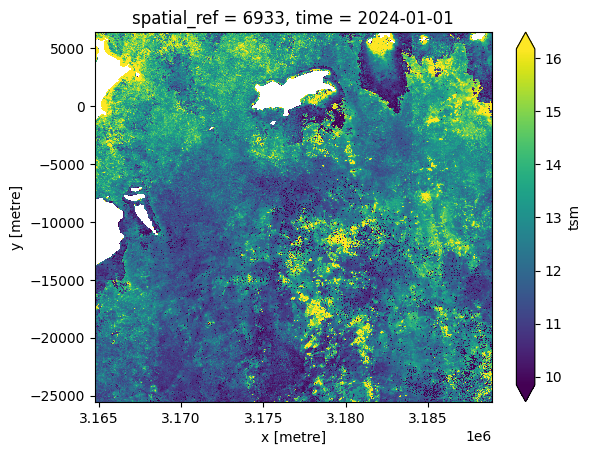

In [16]:
ds.tsm.plot(robust=True)
plt.show()

## Apply water quality algorithm to individual timesteps

### Load in individual timestep Landsat data
Next, rather than use the annual water quality data, we load in inidividual timesteps of satellite data and apply the water quality algorithm to the timesteps. We will use the Floating Algae Index (FAI) as an example.

In [17]:
# Open the stac catalogue
catalog = Client.open("https://explorer.digitalearth.africa/stac")

In [18]:
# Build a query with the set parameters
query = catalog.search(
    bbox=bbox, collections=["ls8_sr"], datetime=f"{start_date}/{end_date}"
)

# Search the STAC catalog for all items matching the query
items = list(query.items())
print(f"Found: {len(items):d} datasets")

Found: 4 datasets


In [19]:
ls_ds = stac_load(
    items,
    crs=crs,
    resolution=30,
    chunks={},
    bbox=bbox,
)

In [20]:
ls_ds

<xarray.Dataset> Size: 151MB
Dimensions:                    (y: 1064, x: 805, time: 4)
Coordinates:
  * y                          (y) float64 9kB 6.375e+03 ... -2.552e+04
  * x                          (x) float64 6kB 3.165e+06 3.165e+06 ... 3.189e+06
  * time                       (time) datetime64[ns] 32B 2024-01-03T08:01:25....
    spatial_ref                int32 4B 6933
Data variables:
    SR_B1                      (time, y, x) float32 14MB dask.array<chunksize=(1, 1064, 805), meta=np.ndarray>
    SR_B2                      (time, y, x) float32 14MB dask.array<chunksize=(1, 1064, 805), meta=np.ndarray>
    SR_B3                      (time, y, x) float32 14MB dask.array<chunksize=(1, 1064, 805), meta=np.ndarray>
    SR_B4                      (time, y, x) float32 14MB dask.array<chunksize=(1, 1064, 805), meta=np.ndarray>
    SR_B5                      (time, y, x) float32 14MB dask.array<chunksize=(1, 1064, 805), meta=np.ndarray>
    SR_B6                      (time, y, x) float32 14MB dask.array<chunksize=(1, 1064, 805), meta=np.ndarray>
    SR_B7                      (time, y, x) float32 14MB dask.array<chunksize=(1, 1064, 805), meta=np.ndarray>
    QA_PIXEL                   (time, y, x) float32 14MB dask.array<chunksize=(1, 1064, 805), meta=np.ndarray>
    QA_RADSAT                  (time, y, x) float32 14MB dask.array<chunksize=(1, 1064, 805), meta=np.ndarray>
    SR_QA_AEROSOL              (time, y, x) float32 14MB dask.array<chunksize=(1, 1064, 805), meta=np.ndarray>
    reduced_resolution_browse  (time, y, x) float32 14MB dask.array<chunksize=(1, 1064, 805), meta=np.ndarray>

In [21]:
def rename_oli_bands(ds):
    rename_dict = {
        "SR_B2": "oli02",
        "SR_B3": "oli03",
        "SR_B4": "oli04",
        "SR_B5": "oli05",
        "SR_B6": "oli06",
        "SR_B7": "oli07",
    }
    
    # Only rename variables that actually exist in ds
    rename_dict = {k: v for k, v in rename_dict.items() if k in ds.data_vars}
    
    return ds.rename(rename_dict)

In [22]:
ds_ls = rename_oli_bands(ls_ds)

### Load in annual Water Observations data to keep only wet pixels
We calculate the 5-year wetness frequency of pixels, centred around 2024, and use it to construct a mask to keep only pixels that are wet more often than not.

In [24]:
# For centred 2024, attempt 2022–2026
search = catalog.search(
    collections=["wofs_ls_summary_annual"],
    bbox=bbox,
    datetime="2022-01-01/2025-12-31"
)

items = search.item_collection()

items

In [25]:
ds_wofs = stac_load(
    items,
    bbox=bbox,
    crs="EPSG:6933",
    resolution=30,
    chunks={}
)

In [26]:
wet_5yr = ds_wofs.count_wet.rolling(
    time=5,
    center=True,
    min_periods=4 # Allow NaNs for 2026
).sum()

clear_5yr = ds_wofs.count_clear.rolling(
    time=5,
    center=True,
    min_periods=4
).sum()

freq_5yr = wet_5yr / clear_5yr

freq_2024 = freq_5yr.sel(time="2024")

### Apply the FAI algorithm to individual timesteps

In [27]:
fai_ls = FAI(ds_ls, instrument='oli')

In [31]:
# Create a mask from pixels that are wet more often than not
wet_mask = freq_2024 > 0.5

# Broadcast the mask to all timesteps and apply it
wet_mask_expanded = wet_mask.isel(time=0).broadcast_like(fai_ls)
fai_ls_wet = xr.where(wet_mask_expanded, fai_ls, np.nan)

### Plot the FAI data
We use a blue-green colour scheme such that darker green values indicate a higher FAI.

/opt/venv/lib/python3.12/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)


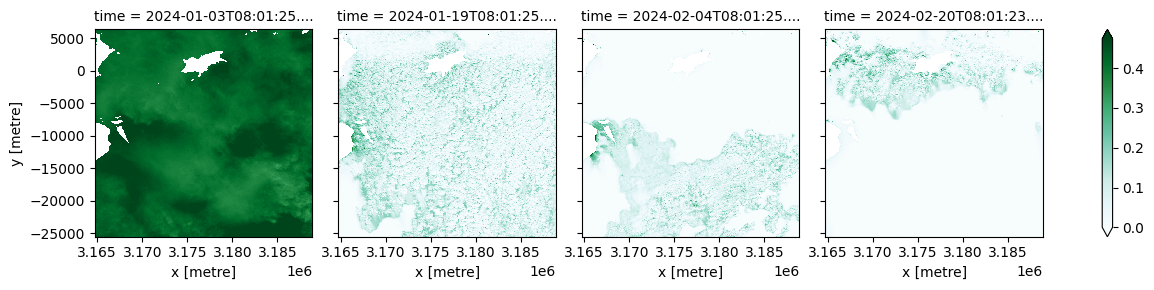

In [34]:
fai_ls_wet.plot(
    col="time",
    col_wrap=4, 
    cmap="BuGn",
    robust=True,
    vmin=0
)

## Apply change detection to identify threshold exceedances
We use a FAI threshold of 0.1, above which values are unlikely to be noise.

In [35]:
# Define threshold
threshold = 0.1

# Compute spatial mean over y/x ignoring NaNs
mean_fai = fai_ls_wet.mean(dim=("y", "x"), skipna=True)

# Build a pandas DataFrame
fai_summary = pd.DataFrame({
    "time": mean_fai.time.values,
    "mean_fai": mean_fai.values,
    "above_threshold": mean_fai.values > threshold
})

# Light pastel colors for readability
def highlight_threshold(val):
    color = '#ff9999' if val else '#b3ffb3'  # light red / light green
    return f'background-color: {color}'

# Apply styling
fai_summary.style.map(highlight_threshold, subset=['above_threshold'])

/opt/venv/lib/python3.12/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/opt/venv/lib/python3.12/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)


,time,mean_fai,above_threshold
0,2024-01-03 08:01:25.176404,0.426036,True
1,2024-01-19 08:01:25.862832,0.065402,False
2,2024-02-04 08:01:25.069829,0.024477,False
3,2024-02-20 08:01:23.472667,0.011803,False


***

## Additional information

**License:** The code in this notebook is licensed under the [Apache License, Version 2.0](https://www.apache.org/licenses/LICENSE-2.0). 
Digital Earth Africa data is licensed under the [Creative Commons by Attribution 4.0](https://creativecommons.org/licenses/by/4.0/) license.

**Contact:** If you need assistance, please post a question on the [Open Data Cube Slack channel](http://slack.opendatacube.org/) or on the [GIS Stack Exchange](https://gis.stackexchange.com/questions/ask?tags=open-data-cube) using the `open-data-cube` tag (you can view previously asked questions [here](https://gis.stackexchange.com/questions/tagged/open-data-cube)).
If you would like to report an issue with this notebook, you can file one on [Github](https://github.com/digitalearthafrica/deafrica-sandbox-notebooks).

**Compatible datacube version:** 

In [23]:
print(datacube.__version__)

1.9.13


**Last Tested:**

In [24]:
from datetime import datetime
datetime.today().strftime('%Y-%m-%d')

'2026-03-03'